# Perform a fit to a coupled CEF-phonon model using PyCrystalField

Allen Scheie, July 2026

In [66]:
## --- import libraries ------
import numpy as np
import matplotlib.pyplot as plt
import PyCrystalField as cef
from copy import deepcopy
## -------------

<ErrorbarContainer object of 3 artists>

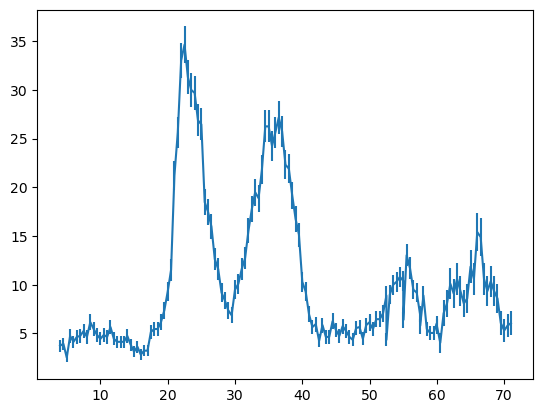

In [67]:
data = np.genfromtxt('LiYbS2_BTsorted.dat', unpack=True)[:,6:-1]

plt.figure()
plt.errorbar(data[0], data[1], data[2])

In [68]:
ciffile = 'LiYbS2_DFT-relaxed.cif'
YbLig1, Yb = cef.importCIF(ciffile, 'Yb', NumIonNeighbors=2) # Generates point charge model 
Yb1 = deepcopy(Yb)

LigandCharges = [-4.8,1.33]
symequivlabels = [0]*6 + [1]*6  ## This must be set by hand
Yb0 = YbLig1.PointChargeModel(symequiv = symequivlabels, LigandCharge=LigandCharges)
Yb = YbLig1.PointChargeModel(symequiv = symequivlabels, LigandCharge=LigandCharges)

unit cell: 3.842 3.842 18.54 90.0 90.0 120.0
Importing atoms
   12 atoms added
.cif import complete.
Central ion: Yb3+ at [0.0, 0.0, 0.0]
    AAAH! There is a super-close atom. Removing it...
 Nearest ligand: S2-
 Next Nearest ligand: Li1+
   Identified 6 S2- ligands.
   Identified 6 Li1+ ligands.
   Found 3 fold axis about [0. 0. 2.]
   Found mirror plane: [1. 0. 0.]

  Axes for point charge model (in ABC space):
        X axis = [-0.5 -1.   0. ] 
        Y axis = [1. 0. 0.] 
        Z axis = [0. 0. 1.] 

   Creating a point charge model...
B_2 0  =  -0.63537743
B_2 1  =  1e-08
B_2 2  =  -0.0
B_4 0  =  0.01084168
B_4 1  =  -0.0
B_4 2  =  -0.0
B_4 3  =  -0.31805999
B_4 4  =  -0.0
B_6 0  =  4.031e-05
B_6 1  =  -0.0
B_6 2  =  0.0
B_6 3  =  0.00086814
B_6 4  =  0.0
B_6 5  =  -0.0
B_6 6  =  0.00038544
B_2 0  =  -0.41079106
B_2 1  =  3e-08
B_2 2  =  -0.0
B_4 0  =  0.02661494
B_4 1  =  -0.0
B_4 2  =  -0.0
B_4 3  =  -0.74608816
B_4 4  =  -0.0
B_6 0  =  9.198e-05
B_6 1  =  -0.0
B_6 2  =  0.0
B

[1.82449642e+02 2.32643360e+01 4.01973464e+00 1.88830649e+02
 3.56678923e+01 6.09254969e+00 3.72043984e+01 5.49025154e+01
 4.08504857e+00 5.09613947e+01 6.57315567e+01 4.85868679e+00
 4.87374446e-02 1.55378325e+00 1.63703214e+00]
bg vals:  [0.04873744 1.55378325]


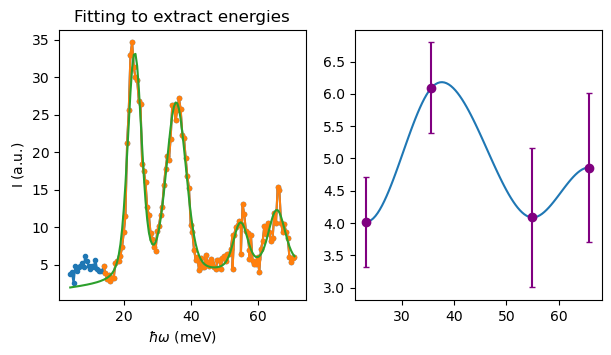

In [69]:
## Define resolution function ##
#######################
from scipy.special import wofz
from scipy.optimize import curve_fit, minimize

def gaus(x, a, x0, sig):
    return a/(np.sqrt(2.*np.pi)*sig)*np.exp(-np.power((x - x0)/sig, 2.)/2.)

def voigt(x, x0, alpha, gamma):
    """ Return the Voigt line shape at x with Lorentzian component FWHM gamma
    and Gaussian component FWHM alpha."""
    sigma = (0.5*alpha) / np.sqrt(2 * np.log(2))
    return np.real(wofz(((x-x0) + 1j*(0.5*gamma))/sigma/np.sqrt(2))) / sigma\
                                                        /np.sqrt(2*np.pi)

#######################

def background(x, aa, bb):
    return aa*x + bb


def gausfitfun(x, a0,x0,w0, a1,x1,w1, a2,x2,w2, a3,x3,w3, aa, bb, lw):
    '''five Voigt functions for the five peaks. Each has its own Gaussian width,
    but all have the same Lorentzian width "lw".'''
    return a0*voigt(x,x0,w0, lw) +\
           a1*voigt(x,x1,w1, lw) +\
           a2*voigt(x,x2,w2, lw) +\
           a3*voigt(x,x3,w3, lw) + background(x, aa, bb)

# Make a guess at the starting parameters:
p0 = [5.6,25,3,  2,35,3,  2.5,55,3, 2.5,65,3, 0, 5, 1]

# Plot results
f, ax = plt.subplots(1,2, figsize=(7,3.5))
ax[0].plot(data[0], data[1], marker='.')
ax[0].plot(data[0][20:], data[1][20:], marker='.')
# ax[0].plot(data[0], gausfitfun(data[0], *p0), zorder=10)
# ax[0].plot(data[0], background(data[0]), ls='--')
ax[0].set_xlabel('$\\hbar \\omega$ (meV)')
ax[0].set_ylabel('$\\rm I$ (a.u.)')
ax[0].set_title('Fitting to extract energies')

poptinitial, pcovinitial = curve_fit(gausfitfun, data[0][20:], data[1][20:], p0=p0)
uncinitial = np.sqrt(np.diag(pcovinitial))
print(poptinitial)

ax[0].plot(data[0], gausfitfun(data[0], *poptinitial), zorder=10)

ObservedEnergies, DOE = [poptinitial[3*i+1] for i in range(0,4)],  [uncinitial[3*i+1] for i in range(0,4)], 
ObservedWidths, DOW =  [poptinitial[3*i+2] for i in range(0,4)], [uncinitial[3*i+2] for i in range(0,4)]
## Set values for fit
alpha = np.mean(ObservedWidths)
gamma = poptinitial[-1]
bg_val = poptinitial[-2]

ax[1].errorbar(ObservedEnergies, ObservedWidths, xerr = DOE, yerr = DOW, capsize=2, marker='o', 
               ls='none', color='purple', label='Obs. peaks')


##-----------------------------------------------------------
## Define background function
def fitbg(x):
    return background(x, *poptinitial[-3:-1])
print('bg vals: ', poptinitial[-3:-1])

##-----------------------------------------------------------
## Define resolution function
from scipy.interpolate import make_interp_spline
# ObservedEnergies = np.hstack((ObservedEnergies[0], ObservedEnergies[0]*1.05, ObservedEnergies[1:]))
# ObservedWidths = np.hstack((ObservedWidths[0], ObservedWidths))
ResFunc = make_interp_spline(ObservedEnergies, ObservedWidths, k=3, bc_type="clamped")
# plot 
xoe = np.linspace(np.min(ObservedEnergies), np.max(ObservedEnergies), 101)
ax[1].plot(xoe, ResFunc(xoe))

Text(0.5, 1.0, 'Initial PC model')

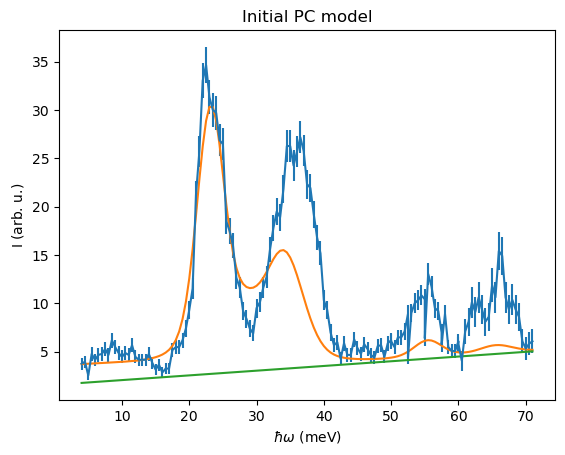

In [70]:
## DEFINE PHONON-CEF Hamiltonian

DistortionB = [0.8119668,  0.03810741, 0.09849757]
ion = 'Yb3+'
ionJ = cef.Jion[ion][-1]
PhononOO =  cef.StevensOp(ionJ,n=2,m=0) * DistortionB[0] +\
            cef.StevensOp(ionJ,n=2,m=1) * DistortionB[1] +\
            cef.StevensOp(ionJ,n=2,m=2) * DistortionB[2]

################

Yb_CFPH = cef.CEF_Phon_obj(Yb, PhononOO)

## test by computing a spectrum
Yb_CFPH.diagonalize(phononE = 28, coupling = 1)
nns = Yb_CFPH.normalizedCEFNeutronSpectrum(data[0], ResFunc=ResFunc, gamma=gamma, Temp =5)

#### Plot
plt.figure()
plt.errorbar(data[0], data[1], data[2])
plt.plot(data[0], nns*35 + fitbg(data[0]))
plt.plot(data[0], fitbg(data[0]))
plt.xlabel('$\\hbar \\omega$ (meV)')
plt.ylabel('$\\rm I$ (arb. u.)')
plt.title('Initial PC model')

## Step 1: fit effective charges

In [ ]:
def err_global(CFPH_Object, LigandCharges, gamma, prefactor, phonE, CPcoupling):
    """Global error function used for fitting"""

    ## Recompute point charge model
    Yb = YbLig1.PointChargeModel(symequiv = symequivlabels, LigandCharge=LigandCharges, printB=False)
    
    # define new Hamiltonian
    CFPH_Object.newCEFCoeff(np.array(Yb.B))
    CFPH_Object.diagonalize(phonE, CPcoupling)

    # compute CEF neutron spectrum
    Nspec_CEF = CFPH_Object.normalizedCEFNeutronSpectrum(Earray=data[0], Temp = 5, 
                   ResFunc=ResFunc, gamma=gamma )

    # Compute error in neutron spectrum
    erro = np.sum(((prefactor*Nspec_CEF + fitbg(data[0]) - data[1])/data[2])**2)

    return erro / (len(data[0]) - 5)


#************************************************************
# Fit to neutron data

FitCoefRes2 = Yb_CFPH.fitdata(chisqfunc = err_global,  
                              fitargs = ['LigandCharges','prefactor', 'phonE', 'CPcoupling'], 
            LigandCharges=[-4.8,1.33],  gamma=gamma/2, prefactor=33, phonE = 28, CPcoupling=1.0)

print('**' + '-'*40)
print(FitCoefRes2)

Initial err= 10.54775708276595 

7.802467776755677
10.54775708276595
Initial err = 10.54775708276595 	Final err = 7.802467776755677
**----------------------------------------
{'LigandCharges': array([-4.92869614,  1.43509555]), 'prefactor': array([39.61521544]), 'phonE': array([28.01653254]), 'CPcoupling': array([0.95716706]), 'Chisq': 7.802467776755677}


Text(0.5, 1.0, 'Fitted PC model')

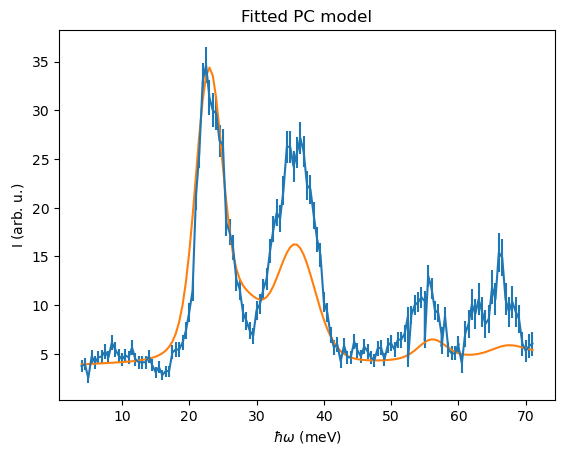

In [72]:
## Compute the new spectrum
Yb2 = YbLig1.PointChargeModel(symequiv = symequivlabels, 
                             LigandCharge=FitCoefRes2['LigandCharges'], printB=False)
Yb_CFPH.newCEFCoeff(Yb2.B)
Yb_CFPH.diagonalize(phononE = FitCoefRes2['phonE'], coupling = 1)

nns = Yb_CFPH.normalizedCEFNeutronSpectrum(data[0], ResFunc=ResFunc, gamma=gamma, Temp=5)

#### Plot
plt.figure()
plt.errorbar(data[0], data[1], data[2])
plt.plot(data[0], nns*FitCoefRes2['prefactor'] + fitbg(data[0]))
plt.xlabel('$\\hbar \\omega$ (meV)')
plt.ylabel('$\\rm I$ (arb. u.)')
plt.title('Fitted PC model')

# Now, fit the CEF parameters directly

In [73]:
def err_global(CFPH_Object, coeff, gamma, prefactor, phonE, CPcoupling):
    """Global error function used for fitting"""
    
    # define new Hamiltonian
    CFPH_Object.newCEFCoeff(coeff)
    CFPH_Object.diagonalize(phonE, CPcoupling)

    # compute CEF neutron spectrum
    Nspec_CEF = CFPH_Object.normalizedCEFNeutronSpectrum(Earray=data[0], Temp = 5, 
                   ResFunc=ResFunc, gamma=gamma )

    # Compute error in neutron spectrum
    erro = np.sum(((prefactor*Nspec_CEF + fitbg(data[0]) - data[1])/data[2])**2)

    return erro/(len(data[0]) - 9)


#************************************************************
# Fit to neutron data, using best fit point charge parameters as starting point
startingcoeff = Yb2.B

FitCoefRes3 = Yb_CFPH.fitdata(chisqfunc = err_global,  fitargs = ['coeff','prefactor', 'phonE', 'CPcoupling'], 
            coeff = startingcoeff,  gamma=gamma/2, prefactor=40, phonE = 29, CPcoupling=0.9)

print('**' + '-'*40)
print(Yb0.B)
print(FitCoefRes3)

Initial err= 9.612491002133764 

2.3385997415454587
9.612491002133764
Initial err = 9.612491002133764 	Final err = 2.3385997415454587
**----------------------------------------
[-0.41079106044866764, 0.026614935530198197, -0.7460881609066108, 9.197758362054511e-05, 0.0019776439998707147, 0.0009284006003773807]
{'coeff': array([-2.54933096e-01,  5.97714568e-03, -6.32319990e-01,  3.03960209e-04,
        1.94647850e-02, -3.35919642e-03]), 'prefactor': array([53.9508836]), 'phonE': array([28.28595204]), 'CPcoupling': array([0.54860924]), 'Chisq': 2.3385997415454587}


Text(0.5, 1.0, 'Final fitted model')

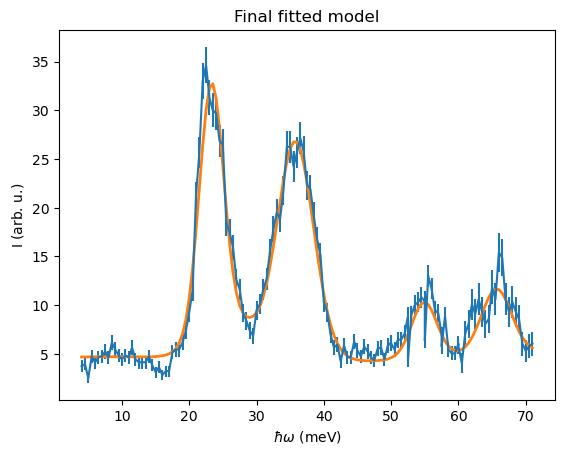

In [74]:
## compute the fitted spectrum
Yb_CFPH.newCEFCoeff(FitCoefRes3['coeff'])
Yb_CFPH.diagonalize(phononE = FitCoefRes3['phonE'], coupling = FitCoefRes3['CPcoupling'])

nns = Yb_CFPH.normalizedCEFNeutronSpectrum(data[0], ResFunc=ResFunc, gamma=gamma/2, Temp=5)

#### Plot
plt.figure()
plt.errorbar(data[0], data[1], data[2])
plt.plot(data[0], nns*FitCoefRes3['prefactor'] + fitbg(data[0]), lw=2)
plt.xlabel('$\\hbar \\omega$ (meV)')
plt.ylabel('$\\rm I$ (arb. u.)')
plt.title('Final fitted model')

In [ ]:
### ------ Print the final fitted Eigenspectrum ------
Yb_CFPH.cefobj.printEigenvectors()


 Eigenvalues 	 Eigenvectors
		---------------------------------------------------------------
0.00000 	|  [ 0.238  0.     0.    -0.648  0.     0.    -0.724  0.   ]  |
0.00000 	|  [ 0.     0.724  0.     0.    -0.648  0.     0.    -0.238]  |
25.41691 	|  [ 0.904  0.     0.    -0.125  0.     0.     0.409  0.   ]  |
25.41691 	|  [ 0.    -0.409  0.     0.    -0.125  0.     0.    -0.904]  |
35.94843 	|  [ 0.  0. -1.  0.  0.  0.  0.  0.]  |
35.94843 	|  [0. 0. 0. 0. 0. 1. 0. 0.]  |
63.76669 	|  [ 0.    -0.556  0.     0.    -0.752  0.     0.     0.355]  |
63.76669 	|  [ 0.355  0.     0.     0.752  0.     0.    -0.556  0.   ]  |
		---------------------------------------------------------------

